In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

In [3]:
BASE_PATH = "/content/drive/MyDrive/electricity-load-system"

file_path = f"{BASE_PATH}/data/processed/day2_features.csv"

df = pd.read_csv(file_path, parse_dates=["datetime"])
df.head()

,datetime,Global_active_power,trend_30,day_of_week,rolling_mean_7,rolling_std_7,z_score,anomaly
0,2006-12-16,3.053475,NaN,Saturday,NaN,NaN,NaN,False
1,2006-12-17,2.354486,NaN,Sunday,NaN,NaN,NaN,False
2,2006-12-18,1.530435,NaN,Monday,NaN,NaN,NaN,False
3,2006-12-19,1.157079,NaN,Tuesday,NaN,NaN,NaN,False
4,2006-12-20,1.545658,NaN,Wednesday,NaN,NaN,NaN,False


In [4]:
for lag in [1, 2, 3, 7, 14]:
    df[f"lag_{lag}"] = df["Global_active_power"].shift(lag)

df.head(10)

,datetime,Global_active_power,trend_30,day_of_week,rolling_mean_7,rolling_std_7,z_score,anomaly,lag_1,lag_2,lag_3,lag_7,lag_14
0,2006-12-16,3.053475,NaN,Saturday,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
1,2006-12-17,2.354486,NaN,Sunday,NaN,NaN,NaN,False,3.053475,NaN,NaN,NaN,NaN
2,2006-12-18,1.530435,NaN,Monday,NaN,NaN,NaN,False,2.354486,3.053475,NaN,NaN,NaN
3,2006-12-19,1.157079,NaN,Tuesday,NaN,NaN,NaN,False,1.530435,2.354486,3.053475,NaN,NaN
4,2006-12-20,1.545658,NaN,Wednesday,NaN,NaN,NaN,False,1.157079,1.530435,2.354486,NaN,NaN
5,2006-12-21,1.193758,NaN,Thursday,NaN,NaN,NaN,False,1.545658,1.157079,1.530435,NaN,NaN
6,2006-12-22,1.625929,NaN,Friday,1.780117,0.686102,-0.224730,False,1.193758,1.545658,1.157079,NaN,NaN
7,2006-12-23,3.314851,NaN,Saturday,1.817457,0.769050,1.947070,False,1.625929,1.193758,1.545658,3.053475,NaN
8,2006-12-24,1.770842,NaN,Sunday,1.734079,0.731863,0.050232,False,3.314851,1.625929,1.193758,2.354486,NaN
9,2006-12-25,1.904944,NaN,Monday,1.787580,0.728174,0.161176,False,1.770842,3.314851,1.625929,1.530435,NaN


In [5]:
df = df.dropna()
df.shape

(1259, 13)

In [6]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train[[f"lag_{l}" for l in [1,2,3,7,14]]]
y_train = train["Global_active_power"]

X_test = test[[f"lag_{l}" for l in [1,2,3,7,14]]]
y_test = test["Global_active_power"]

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [9]:
mae_lr = mean_absolute_error(y_test, lr_preds)
mse_lr = mean_squared_error(y_test, lr_preds)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 0.18419422646646502
Linear Regression RMSE: 0.2460936158451968


In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [12]:
mae_rf = mean_absolute_error(y_test, rf_preds)
mse_rf = mean_squared_error(y_test, rf_preds)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 0.18187419405876595
Random Forest RMSE: 0.24812759422947994


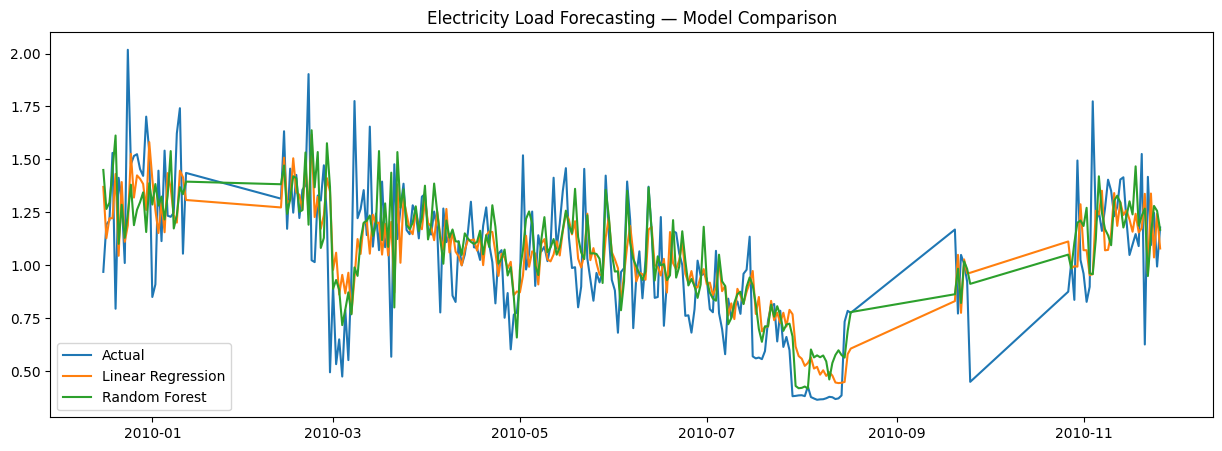

In [13]:
plt.figure(figsize=(15,5))
plt.plot(test["datetime"], y_test.values, label="Actual")
plt.plot(test["datetime"], lr_preds, label="Linear Regression")
plt.plot(test["datetime"], rf_preds, label="Random Forest")
plt.legend()
plt.title("Electricity Load Forecasting — Model Comparison")
plt.show()

In [16]:
import os

models_dir = f"{BASE_PATH}/models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(lr, f"{models_dir}/linear_regression.pkl")
joblib.dump(rf, f"{models_dir}/random_forest.pkl")

['/content/drive/MyDrive/electricity-load-system/models/random_forest.pkl']

In [17]:
!mkdir -p /content/drive/MyDrive/electricity-load-system/models